# Kerckhoffs Robustness Experiment

Measures evasion robustness of IDS detection rules generated by five conditions
(LLM_orig, LLM_anon, DT_d3, DT_d5, RF_d5) across CIC-IoT2023 and WUSTL-IIoT.

**Metric:** Evasion Success Rate (ESR) as a function of perturbation budget ε (std units).
**Key result:** ε at ESR=0.5 — the median evasion cost per condition.

Run all cells in order (Kernel → Restart & Run All).

In [1]:
################################################################################
# Cell 0 — Configuration
################################################################################

import sys, os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

# Notebook lives at iot-llm-hids-pg/experiments/
# BASE  = iot-llm-hids-pg/
# DATA_ROOT = RAG Paper/   (parent of iot-llm-hids-pg, contains data/)
NOTEBOOK_DIR = Path.cwd()
BASE         = NOTEBOOK_DIR.parent
DATA_ROOT    = NOTEBOOK_DIR.parent.parent
RESULTS_ROOT = DATA_ROOT / 'iot-llm-hids-pg-results'

DATASETS = [
    {
        'name':           'cic-iot',
        'path':           str(DATA_ROOT / 'data/cic-iot/CSV/cic-iot-2023-population.csv'),
        'label_col':      'label',
        'benign_class':   'BenignTraffic',
        'withheld_class': 'Mirai-udpplain',
        'drop_cols':      ['label'],
        # LLM result files
        'llm_orig_glob':  str(RESULTS_ROOT / '1-cic-iot/llm/zeroday-Mirai-udpplain-seed42-*.json'),
        'llm_anon_glob':  str(RESULTS_ROOT / '1-cic-iot/anon/zeroday-Mirai-udpplain-anon-ablation-seed42-*.json'),
        'llm_anon_save_dir': str(RESULTS_ROOT / '1-cic-iot/anon'),
        'anon_map_file':  str(RESULTS_ROOT / '1-cic-iot/anon/cic-iot-anon-ablation.json'),
        # flat = top-level 'rules' key; nested = 'original'/'anonymized' sub-dicts
        'llm_json_format': 'flat',
    },
    {
        'name':           'wustl-iiot',
        'path':           str(DATA_ROOT / 'data/wustl-iiot/wustl-iiot-population.csv'),
        'label_col':      'Traffic',
        'benign_class':   'normal',
        'withheld_class': 'Reconn',
        'drop_cols':      ['Target', 'Traffic'],
        'llm_orig_glob':  None,   # orig rules are inside the anon-ablation file
        'llm_anon_glob':  str(RESULTS_ROOT / '2-wustl-iiot/anon/zeroday-Reconn-anon-ablation-seed42-*.json'),
        'llm_anon_save_dir': None,
        'anon_map_file':  None,
        'llm_json_format': 'nested',
    },
]

EPSILONS  = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]
SEEDS     = [42, 123, 456]
SEED_MAIN = 42

OUT_DIR = Path('results/kerckhoffs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONDITIONS = ['LLM_orig', 'LLM_anon', 'DT_d3', 'DT_d5', 'RF_d5']

print(f'BASE      : {BASE}')
print(f'DATA_ROOT : {DATA_ROOT}')
print(f'OUT_DIR   : {OUT_DIR.resolve()}')
print(f'Datasets  : {[d["name"] for d in DATASETS]}')
print(f'Conditions: {CONDITIONS}')
print(f'Epsilons  : {EPSILONS}')


BASE      : /Users/S4160163/Documents/Projects/RAG Paper/iot-llm-hids-pg
DATA_ROOT : /Users/S4160163/Documents/Projects/RAG Paper
OUT_DIR   : /Users/S4160163/Documents/Projects/RAG Paper/iot-llm-hids-pg/experiments/results/kerckhoffs
Datasets  : ['cic-iot', 'wustl-iiot']
Conditions: ['LLM_orig', 'LLM_anon', 'DT_d3', 'DT_d5', 'RF_d5']
Epsilons  : [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]


In [2]:
################################################################################
# Cell 1 — Helper functions
################################################################################

import glob, json, datetime, operator as op_module
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from statistics import mode

operators = {
    '<':  op_module.lt, '>':  op_module.gt,
    '<=': op_module.le, '>=': op_module.ge,
    '==': op_module.eq, '!=': op_module.ne,
}


# ── Dataset loading ───────────────────────────────────────────────────────────

def load_dataset(config, seed=42):
    """
    Load CSV, build balanced binary pool (1:1 benign:known-attack),
    stratified 80/20 split.  feature_stds computed on train only.
    Returns (train_df, test_known_df, zeroday_df, feature_cols, feature_stds).
    """
    df_raw = pd.read_csv(config['path'])
    drop   = set(config['drop_cols'])
    feature_cols = [
        c for c in df_raw.select_dtypes(include=[np.number]).columns
        if c not in drop
    ]
    df = df_raw[feature_cols + [config['label_col']]].copy()

    lc  = config['label_col']
    ben = config['benign_class']
    wh  = config['withheld_class']

    benign_df    = df[df[lc] == ben].copy()
    known_atk_df = df[(df[lc] != ben) & (df[lc] != wh)].copy()
    zeroday_df   = df[df[lc] == wh].copy()

    target_n = min(len(benign_df), len(known_atk_df))
    pool = pd.concat([
        benign_df.sample(n=target_n, random_state=seed),
        known_atk_df.sample(n=target_n, random_state=seed),
    ], ignore_index=True)
    pool['binary_label'] = pool[lc].apply(lambda x: 'normal' if x == ben else 'attack')

    train_idx, test_idx = train_test_split(
        pool.index, test_size=0.2, random_state=seed, stratify=pool['binary_label']
    )
    train_df      = pool.loc[train_idx].reset_index(drop=True)
    test_known_df = pool.loc[test_idx].reset_index(drop=True)

    feature_stds = train_df[feature_cols].std()   # training-data std only
    zeroday_out  = zeroday_df[feature_cols].reset_index(drop=True)

    print(f"  [{config['name']}] train={len(train_df):,}  "
          f"test_known={len(test_known_df):,}  "
          f"zeroday={len(zeroday_out):,}  features={len(feature_cols)}")
    return train_df, test_known_df, zeroday_out, feature_cols, feature_stds


# ── LLM rule loading ──────────────────────────────────────────────────────────

def load_llm_rules(config, condition, seed=42):
    """
    Load LLM rules from JSON result file.
    Returns list of {'feature': str, 'op': str, 'threshold': float}.
    For anonymized rules, 'real_name' is used as the feature key.
    """
    if condition == 'LLM_orig':
        pattern = config['llm_orig_glob'] or config['llm_anon_glob']
    else:
        pattern = config['llm_anon_glob']

    files = sorted(glob.glob(pattern))

    if not files and condition == 'LLM_anon' and config['llm_json_format'] == 'flat':
        print(f'  CIC-IoT anon result not found — generating (seed={seed})...')
        _generate_cic_anon_rules(config, seed)
        files = sorted(glob.glob(pattern))

    if not files:
        raise FileNotFoundError(f'No LLM result file for pattern: {pattern}')

    with open(files[-1]) as f:
        data = json.load(f)

    if config['llm_json_format'] == 'flat':
        raw = data['rules']
        # Use real_name when present (generated anon file has both feature_name=fN
        # and real_name=actual col); fall back to feature_name for orig files.
        rules = [{'feature': r.get('real_name', r['feature_name']), 'op': r['op'],
                  'threshold': float(r['value'])} for r in raw]
    else:  # nested: 'original' / 'anonymized'
        key = 'original' if condition == 'LLM_orig' else 'anonymized'
        raw = data[key]['rules']
        rules = []
        for r in raw:
            feat = r.get('real_name', r['feature_name'])
            rules.append({'feature': feat, 'op': r['op'], 'threshold': float(r['value'])})

    print(f'  Loaded {len(rules)} {condition} rules from {Path(files[-1]).name}')
    return rules


# ── CIC-IoT anon rule generation (runs LangGraph pipeline) ────────────────────

def _generate_cic_anon_rules(config, seed):
    """
    Generate anonymized LLM rules for CIC-IoT if result file absent.
    Mirrors the pipeline from 1-cic-iot/04-zero-day-detection-claude.ipynb
    but feeds anonymized feature names (f0, f1, …) to the LLM.
    """
    import dotenv
    from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
    # from langchain_openai import ChatOpenAI
    from langchain_anthropic import ChatAnthropic
    from langchain_core.tools import tool as lc_tool
    from langgraph.graph import MessagesState, StateGraph, START, END
    from langgraph.checkpoint.memory import MemorySaver
    from langchain_huggingface.embeddings import HuggingFaceEmbeddings
    from typing import Annotated

    dotenv.load_dotenv(str(BASE / '.env'))

    train_df, test_known_df, _, feat_cols, _ = load_dataset(config, seed=seed)
    n_tr = train_df[train_df['binary_label'] == 'normal'][feat_cols].reset_index(drop=True)
    a_tr = train_df[train_df['binary_label'] == 'attack'][feat_cols].reset_index(drop=True)
    n_te = test_known_df[test_known_df['binary_label'] == 'normal'][feat_cols].reset_index(drop=True)
    a_te = test_known_df[test_known_df['binary_label'] == 'attack'][feat_cols].reset_index(drop=True)

    # Build anon map dynamically from the loaded feature columns — same as WUSTL notebook.
    # This ensures ALL features get an fi label in the correct order, rather than
    # relying on the pre-existing JSON which may cover fewer features.
    anon_map    = {name: f'f{i}' for i, name in enumerate(feat_cols)}
    reverse_map = {f'f{i}': name for i, name in enumerate(feat_cols)}

    emb = HuggingFaceEmbeddings(
        model_name='BAAI/bge-m3',
        model_kwargs={'device': 'mps'},
        encode_kwargs={'normalize_embeddings': True, 'batch_size': 64},
    )

    def get_repr(df, n=10, max_embed=100, s=42):
        samp = df.sample(n=min(max_embed, len(df)), random_state=s)
        docs = [str(row.tolist()) for _, row in samp.iterrows()]
        vecs = np.array(emb.embed_documents(docs))
        mean = vecs.mean(axis=0)
        nrms = np.linalg.norm(vecs, axis=1) * np.linalg.norm(mean)
        sims = (vecs @ mean) / np.where(nrms == 0, 1e-9, nrms)
        return samp.iloc[np.argsort(sims)[::-1][:n]]

    n_repr = get_repr(n_tr, s=seed)
    a_repr = get_repr(a_tr, s=seed)
    normal_entries = json.dumps({anon_map[c]: n_repr[c].tolist() for c in feat_cols})
    attack_entries = json.dumps({anon_map[c]: a_repr[c].tolist() for c in feat_cols})

    k_rules, n_iter = 5, 5
    _op_fn = {'<': op_module.lt, '>': op_module.gt,
               '<=': op_module.le, '>=': op_module.ge}

    from tqdm import tqdm as _tqdm

    @lc_tool
    def evaluation_tool(
            feature_name: Annotated[str, 'Feature name (anon fi or real)'],
            value: Annotated[float, 'Threshold'],
            op: Annotated[str, 'Operator (<, >, <=, >=)']) -> float:
        """Evaluate threshold rule on training data. Returns macro F1."""
        rn = reverse_map.get(feature_name, feature_name)
        try: value = float(value)
        except: pass
        if op not in _op_fn: return 0.0
        y_t, y_p = [], []
        for lbl, dataset in [('normal', n_tr), ('attack', a_tr)]:
            for i in _tqdm(range(len(dataset)), ncols=100, desc=f'Eval {lbl}...'):
                y_t.append(lbl)
                try: y_p.append('attack' if _op_fn[op](dataset.iloc[i][rn], value) else 'normal')
                except: y_p.append('normal')
        rep = classification_report(y_t, y_p, output_dict=True, zero_division=0)
        return rep['macro avg']['f1-score']

    llm = ChatAnthropic(model='claude-haiku-4-5-20251001', temperature=0.1)
    llm_t = llm.bind_tools([evaluation_tool])

    def _tc(msg):
        p = getattr(msg, 'tool_calls', None)
        if p: return p
        raw = (getattr(msg, 'additional_kwargs', {}) or {}).get('tool_calls', [])
        out = []
        for c in raw:
            fn = c.get('function', {})
            args = fn.get('arguments', {})
            if isinstance(args, str):
                try: args = json.loads(args)
                except: args = {}
            out.append({'id': c.get('id',''), 'name': fn.get('name',''), 'args': args})
        return out

    class St(MessagesState):
        i: int; max_f1s: float; best_tool_calls: list

    def _llm(state):
        return {'messages': [llm_t.invoke(state['messages'])], 'i': state['i'] + 1}

    def _tools(state):
        ai = next(m for m in reversed(state['messages']) if _tc(m))
        res = [ToolMessage(content=str(evaluation_tool.invoke(tc['args'])),
                           tool_call_id=tc['id']) for tc in _tc(ai)]
        return {'messages': res}

    def _eval(state):
        ai_msgs = [m for m in state['messages'] if isinstance(m, AIMessage) and _tc(m)]
        if not ai_msgs: return {}
        tcs = _tc(ai_msgs[-1])
        y_t, y_p = [], []
        for lbl, dataset in [('normal', n_te), ('attack', a_te)]:
            for i in _tqdm(range(len(dataset)), ncols=100, desc=f'Test eval {lbl}...'):
                try:
                    votes = ['attack' if _op_fn[tc['args']['op']](
                                 dataset.iloc[i][reverse_map.get(tc['args']['feature_name'],
                                                                  tc['args']['feature_name'])],
                                 float(tc['args']['value'])) else 'normal'
                             for tc in tcs]
                    y_p.append(mode(votes))
                except: y_p.append('normal')
                y_t.append(lbl)
        rep  = classification_report(y_t, y_p, output_dict=True, zero_division=0)
        f1   = rep['macro avg']['f1-score']
        nmax = max(state['max_f1s'], f1)
        nb   = tcs if f1 >= state['max_f1s'] else state['best_tool_calls']
        fb   = HumanMessage(
            f'Current macro avg F1 on test set (known attacks only): {f1:.4f}. '
            f'Best so far: {nmax:.4f}. '
            f'If this is greater than the previous best, keep performing rules and revise underperforming ones. '
            f'Otherwise revise all rules to exceed the best. '
            f'Generate exactly {k_rules} rules and make a tool call for each.')
        return {'messages': [fb], 'max_f1s': nmax, 'best_tool_calls': nb}

    def _cond_t(s): return 'tools' if _tc(s['messages'][-1]) else 'eval'
    def _cond_f(s): return 'llm' if s['i'] < n_iter else END

    g = StateGraph(St)
    g.add_node('llm', _llm); g.add_node('tools', _tools); g.add_node('eval', _eval)
    g.add_edge(START, 'llm')
    g.add_conditional_edges('llm', _cond_t, ['tools', 'eval'])
    g.add_edge('tools', 'llm')
    g.add_conditional_edges('eval', _cond_f, ['llm', END])
    graph = g.compile(checkpointer=MemorySaver())

    from langchain_core.messages import SystemMessage, HumanMessage
    sys_msg = SystemMessage(
        f'You are a skilled security data analyst.\n'
        f'You are provided with network data entries categorized as either normal or attack, '
        f'along with their corresponding feature names.\n'
        f'Carefully analyze the differences between normal and attack entries by comparing '
        f'corresponding fields.\n'
        f'Your task is to generate exactly {k_rules} simple and deterministic rules for the '
        f'top {k_rules} important features to filter attack entries.\n'
        f'Supported operators: >, <, >=, <=\n'
        f"NEVER use '==' or '!=' - these are forbidden for numeric features.\n"
        f'Generate exactly {k_rules} rules and make a tool call for each rule.')
    hum_msg = HumanMessage(
        f'Analyze the following network data and generate {k_rules} rules to identify attack entries.\n\n'
        f'Normal Entries:\n```{normal_entries}```\n\n'
        f'Attack Entries:\n```{attack_entries}```')
    init = St(i=0, max_f1s=0.5, best_tool_calls=[],
              messages=[sys_msg, hum_msg])
    cfg_ = {'configurable': {'thread_id': f'cic-anon-gen-{seed}'}, 'recursion_limit': 100}
    out  = graph.invoke(init, cfg_)

    best_tcs = out['best_tool_calls']
    ts_str   = datetime.datetime.now().strftime('%Y-%m-%d-%H-%M-%S')
    save_data = {
        'dataset': 'cic-iot',
        'withheld_class': config['withheld_class'],
        'seed': seed,
        'known_f1_anon': out['max_f1s'],
        'rules': [
            {'feature_name': tc['args']['feature_name'],
             'real_name': reverse_map.get(tc['args']['feature_name'],
                                          tc['args']['feature_name']),
             'value': tc['args']['value'],
             'op':    tc['args']['op']}
            for tc in best_tcs
        ],
    }
    os.makedirs(config['llm_anon_save_dir'], exist_ok=True)
    sp = (f"{config['llm_anon_save_dir']}/"
          f"zeroday-{config['withheld_class']}-anon-ablation-seed{seed}-{ts_str}.json")
    with open(sp, 'w') as fh:
        json.dump(save_data, fh, indent=2)
    print(f'  CIC-IoT anon rules saved to {sp}')


# ── ML training ───────────────────────────────────────────────────────────────

def train_ml_baseline(model_class, train_df, feature_cols, params):
    """Fit binary classifier on train_df. Returns fitted model."""
    model = model_class(**params)
    model.fit(train_df[feature_cols].values, train_df['binary_label'].values)
    return model


print('Helper functions defined.')


Helper functions defined.


In [3]:
################################################################################
# Cell 1b — Adversarial rule hardening
################################################################################

def adversarially_harden_rules(
    base_rules, train_df, feature_cols, feature_stds,
    n_augment=None,
    majority_fraction=None,
    atk_pct=None,
    ben_pct=None,
):
    """
    Post-process LLM rules to maximise minimum evasion cost per rule.

    (a) Threshold hardening: reposition each rule's threshold to the midpoint
        of the attack-benign gap, maximising the attacker's perturbation budget.
    (b) Feature-diverse augmentation: add n_augment rules on features NOT in the
        original set, ranked by normalised attack-benign separation.

    Returns: (hardened_rules: list[dict], majority_threshold: int)
    """
    if n_augment        is None: n_augment        = ROBUST_N_AUGMENT
    if majority_fraction is None: majority_fraction = ROBUST_MAJORITY_FRACTION
    if atk_pct          is None: atk_pct          = ROBUST_ATTACK_PERCENTILE
    if ben_pct          is None: ben_pct          = ROBUST_BENIGN_PERCENTILE

    attack_df = train_df[train_df['binary_label'] == 'attack'][feature_cols]
    benign_df = train_df[train_df['binary_label'] == 'normal'][feature_cols]

    hardened = []
    for rule in base_rules:
        feat     = rule['feature']
        op       = rule['op']
        orig_thr = rule['threshold']

        if feat not in attack_df.columns:
            hardened.append(rule.copy())
            continue

        a_vals = attack_df[feat].dropna()
        b_vals = benign_df[feat].dropna()
        if len(a_vals) == 0 or len(b_vals) == 0:
            hardened.append(rule.copy())
            continue

        if op in ('<=', '<'):
            # attacks LOW, benign HIGH — push threshold into the gap
            a_hi = float(np.percentile(a_vals, atk_pct))
            b_lo = float(np.percentile(b_vals, ben_pct))
            new_thr = (a_hi + b_lo) / 2.0 if b_lo > a_hi else orig_thr
        else:  # >= or >
            # attacks HIGH, benign LOW — push threshold into the gap
            a_lo = float(np.percentile(a_vals, 100 - atk_pct))
            b_hi = float(np.percentile(b_vals, 100 - ben_pct))
            new_thr = (a_lo + b_hi) / 2.0 if b_hi < a_lo else orig_thr

        hardened.append({'feature': feat, 'op': op, 'threshold': new_thr})

    # Augmentation: features NOT already covered, sorted by normalised separation
    covered = {r['feature'] for r in hardened}
    candidates = []
    for feat in feature_cols:
        if feat in covered:
            continue
        a_vals = attack_df[feat].dropna()
        b_vals = benign_df[feat].dropna()
        std    = float(feature_stds.get(feat, 0))
        if std == 0 or len(a_vals) == 0 or len(b_vals) == 0:
            continue
        sep = abs(float(a_vals.median()) - float(b_vals.median())) / std
        candidates.append((sep, feat))

    candidates.sort(reverse=True)
    for _, feat in candidates[:n_augment]:
        a_vals = attack_df[feat].dropna()
        b_vals = benign_df[feat].dropna()
        a_med  = float(a_vals.median())
        b_med  = float(b_vals.median())
        if a_med <= b_med:
            op   = '<='
            a_hi = float(np.percentile(a_vals, atk_pct))
            b_lo = float(np.percentile(b_vals, ben_pct))
            thr  = (a_hi + b_lo) / 2.0 if b_lo > a_hi else a_hi
        else:
            op   = '>='
            a_lo = float(np.percentile(a_vals, 100 - atk_pct))
            b_hi = float(np.percentile(b_vals, 100 - ben_pct))
            thr  = (a_lo + b_hi) / 2.0 if b_hi < a_lo else a_lo
        hardened.append({'feature': feat, 'op': op, 'threshold': thr})
        covered.add(feat)

    mt = int(np.ceil(len(hardened) * majority_fraction))
    print(f'  Hardened rules: {len(hardened)} total '
          f'({len(base_rules)} original + {len(hardened) - len(base_rules)} augmented)'
          f' | majority_threshold={mt}')
    return hardened, mt


print('Adversarial hardening function defined.')


Adversarial hardening function defined.


In [4]:
################################################################################
# Cell 2 — Core evasion algorithm (LLM majority-vote rules)
################################################################################


def compute_evasion_cost_per_rule(x, rule, feature_stds):
    """
    Minimum perturbation in std units to make rule NOT fire on x.
    Returns 0.0 if rule already not firing.
    Returns inf if the feature has std=0 (constant — cannot perturb).
    """
    feat  = rule['feature']
    op    = rule['op']
    thr   = rule['threshold']

    if feat not in x.index:
        return 0.0

    val = float(x[feat])
    std = float(feature_stds.get(feat, 0))

    if not operators[op](val, thr):
        return 0.0   # rule not firing — no evasion needed

    if std == 0 or pd.isna(std):
        return float('inf')  # constant feature — impossible to perturb

    if op in ('>', '>='):
        # need val ≤ thr — floor at 1e-15 so a boundary-firing rule (val==thr)
        # still has strictly positive cost (requires ε→0+ perturbation, not zero)
        return max(abs(val - thr) / std, 1e-15)
    elif op in ('<', '<='):
        # need val ≥ thr
        return max(abs(thr - val) / std, 1e-15)
    return float('inf')


def evade_majority_vote(x, rules, feature_stds, epsilon, majority_threshold=None):
    """
    Greedy majority-vote evasion.
    Sort firing rules by cost ascending; flip the cheapest subset until
    fewer than majority_threshold rules fire.
    Per-feature costs are merged (attacker pays once per distinct feature).

    Returns (evaded: bool, total_cost: float, features_perturbed: list[str]).
    """
    k  = len(rules)
    mt = majority_threshold if majority_threshold is not None else (k // 2 + 1)

    costs   = [(i, compute_evasion_cost_per_rule(x, r, feature_stds))
               for i, r in enumerate(rules)]
    firing  = [(i, c) for i, c in costs if c > 0]

    if len(firing) < mt:
        return (True, 0.0, [])

    to_flip = len(firing) - mt + 1
    firing.sort(key=lambda t: t[1])

    feat_costs: dict = {}
    for i, c in firing[:to_flip]:
        f = rules[i]['feature']
        feat_costs[f] = max(feat_costs.get(f, 0.0), c)

    total = sum(feat_costs.values())
    return (total <= epsilon, total, list(feat_costs.keys()))


def predicts_attack_llm(x, rules, majority_threshold=None):
    """True if majority-vote of rules classify x as 'attack'."""
    mt    = majority_threshold if majority_threshold is not None else (len(rules) // 2 + 1)
    votes = sum(
        1 for r in rules
        if r['feature'] in x.index
        and operators[r['op']](float(x[r['feature']]), r['threshold'])
    )
    return votes >= mt


print('Evasion (LLM) functions defined.')


Evasion (LLM) functions defined.


In [5]:
################################################################################
# Cell 3 — DT/RF rule extraction and evasion
################################################################################


def extract_dt_attack_paths(fitted_dt, feature_names):
    """
    Walk sklearn tree_ and collect conjunctive paths to attack-class leaves.
    sklearn sorts classes alphabetically: classes_[0]='attack', [1]='normal'.
    Returns list of paths; each path is list of {'feature', 'op', 'threshold'}.
    """
    tree       = fitted_dt.tree_
    attack_idx = list(fitted_dt.classes_).index('attack')
    left, right = tree.children_left, tree.children_right
    paths = []

    def dfs(node, path):
        if left[node] == -1:   # leaf
            if np.argmax(tree.value[node][0]) == attack_idx:
                paths.append(list(path))
            return
        feat = feature_names[tree.feature[node]]
        thr  = float(tree.threshold[node])
        # left branch: feat <= thr
        dfs(left[node],  path + [{'feature': feat, 'op': '<=', 'threshold': thr}])
        # right branch: feat > thr
        dfs(right[node], path + [{'feature': feat, 'op': '>',  'threshold': thr}])

    dfs(0, [])
    return paths


def _escape_cost_one_path(x, path, feature_stds):
    """
    Min cost to violate at least one condition in path (escape the leaf).
    If any condition is already false the sample isn't in this path → return 0.
    """
    min_cost = float('inf')
    for cond in path:
        feat = cond['feature']
        if feat not in x.index:
            continue
        val = float(x[feat])
        std = float(feature_stds.get(feat, 0))
        op  = cond['op']
        thr = cond['threshold']
        if not operators[op](val, thr):
            return 0.0   # sample isn't in this path at all
        if std == 0 or pd.isna(std):
            cost = float('inf')
        elif op in ('>', '>='):
            cost = max(abs(val - thr) / std, 1e-15)
        else:
            cost = max(abs(thr - val) / std, 1e-15)
        min_cost = min(min_cost, cost)
    return min_cost


def _escape_cost_path_dp(x, path, feature_stds):
    """
    Min cost to violate at least one condition in a known-valid (decision_path)
    path.  Unlike _escape_cost_one_path, this version:
      - does NOT verify conditions (path is trusted from sklearn decision_path)
      - skips NaN feature values (sklearn routes them internally; we can't model
        the perturbation cost, so treat them as unperturbable)
      - applies the 1e-15 floor so boundary-firing conditions have positive cost
    """
    min_cost = float('inf')
    for cond in path:
        feat = cond['feature']
        if feat not in x.index:
            continue
        raw = x[feat]
        if pd.isna(raw):
            continue   # NaN: sklearn routed it, but we cannot perturb it
        val = float(raw)
        std = float(feature_stds.get(feat, 0))
        if std == 0 or pd.isna(std):
            continue   # constant feature: unperturbable
        op, thr = cond['op'], cond['threshold']
        if op in ('>', '>='):
            cost = max(abs(val - thr) / std, 1e-15)
        else:
            cost = max(abs(thr - val) / std, 1e-15)
        min_cost = min(min_cost, cost)
    return min_cost


def _cheapest_feat_in_path(x, path, feature_stds):
    """Return (min_cost, feature_name) for the cheapest-to-perturb condition in path."""
    min_cost, min_feat = float('inf'), None
    for cond in path:
        feat = cond['feature']
        if feat not in x.index: continue
        raw = x[feat]
        if pd.isna(raw): continue
        val = float(raw)
        std = float(feature_stds.get(feat, 0))
        if std == 0 or pd.isna(std): continue
        op, thr = cond['op'], cond['threshold']
        if op in ('>', '>='):
            cost = max(abs(val - thr) / std, 1e-15)
        else:
            cost = max(abs(thr - val) / std, 1e-15)
        if cost < min_cost:
            min_cost, min_feat = cost, feat
    return min_cost, min_feat


def evasion_cost_dt(x, attack_paths, feature_stds):
    """
    DT evasion cost: find which attack-leaf path x follows, then return
    the minimum cost to violate one condition in that path (escaping to any
    other leaf). A sample is in at most one leaf, so we stop at first match.
    """
    for path in attack_paths:
        in_path = all(
            p['feature'] in x.index
            and operators[p['op']](float(x[p['feature']]), p['threshold'])
            for p in path
        )
        if in_path:
            return _escape_cost_one_path(x, path, feature_stds)
    return 0.0   # sample not in any attack leaf


def predicts_attack_dt(x, attack_paths):
    """True if x falls into any attack-leaf path."""
    for path in attack_paths:
        if all(
            p['feature'] in x.index
            and operators[p['op']](float(x[p['feature']]), p['threshold'])
            for p in path
        ):
            return True
    return False


def evade_dt(x, attack_paths, feature_stds, epsilon):
    """DT evasion: returns (evaded, cost, [cheapest_feature])."""
    for path in attack_paths:
        in_path = all(
            p['feature'] in x.index
            and operators[p['op']](float(x[p['feature']]), p['threshold'])
            for p in path
        )
        if not in_path:
            continue
        # Find cheapest-to-violate condition
        best_feat, best_cost = None, float('inf')
        for cond in path:
            feat = cond['feature']
            if feat not in x.index:
                continue
            val = float(x[feat])
            std = float(feature_stds.get(feat, 0))
            op  = cond['op']
            thr = cond['threshold']
            if not operators[op](val, thr):
                # Already violated — not in path
                return (True, 0.0, [])
            if std > 0 and not pd.isna(std):
                raw_c = abs(val - thr) / std if op in ('>', '>=') else abs(thr - val) / std
                c = max(raw_c, 1e-15)
            else:
                c = float('inf')
            if c < best_cost:
                best_cost, best_feat = c, feat
        evaded = best_cost <= epsilon
        return (evaded, best_cost, [best_feat] if best_feat else [])
    return (True, 0.0, [])   # not in any attack leaf


def evasion_cost_rf(x, fitted_rf, feature_cols, feature_stds):
    """
    Greedy RF evasion — probability-averaging model (matches sklearn RF predict).

    sklearn RF predicts 'attack' when mean(p_i) > 0.5, where p_i is the
    attack-sample fraction in the leaf that tree i routes x into.  This is NOT
    a simple count-majority of tree predictions; the two differ whenever leaf
    distributions are not pure (common with max_depth < inf).

    Strategy: sort trees by cost_i / p_i (cheapest per unit of probability
    shifted); flip until mean(p_i) drops to <= 0.5.  Flipping tree i means
    perturbing x to escape its current leaf; we assume its new contribution
    becomes 0 (best-case for attacker — upper bound on evasion cost).

    Uses decision_path for reliable path reconstruction (NaN-aware).
    Approximation: assumes independent per-tree perturbations.
    """
    x_arr   = x[feature_cols].values.reshape(1, -1)
    n_trees = len(fitted_rf.estimators_)

    # Individual tree estimators store classes_ as numeric indices [0,1,...];
    # the string→index mapping lives only in fitted_rf.classes_.
    rf_classes = list(fitted_rf.classes_)
    atk_idx    = rf_classes.index('attack')   # same index used by every tree

    tree_entries = []   # (p_i, cost_i, feat_i)
    for est in fitted_rf.estimators_:
        # leaf attack probability
        leaf_id  = est.apply(x_arr)[0]
        tree     = est.tree_
        leaf_val = tree.value[leaf_id][0]
        if len(leaf_val) <= atk_idx:
            # tree was trained on a single-class bootstrap — no attack leaf
            tree_entries.append((0.0, float('inf'), None))
            continue
        p_i = leaf_val[atk_idx] / leaf_val.sum()

        # escape cost + cheapest feature via decision_path (handles NaN correctly)
        node_ids = est.decision_path(x_arr).indices.tolist()
        path = []
        for i, ni in enumerate(node_ids[:-1]):
            feat_name = feature_cols[tree.feature[ni]]
            thr       = float(tree.threshold[ni])
            next_ni   = node_ids[i + 1]
            op = '<=' if next_ni == tree.children_left[ni] else '>'
            path.append({'feature': feat_name, 'op': op, 'threshold': thr})
        cost_i, feat_i = _cheapest_feat_in_path(x, path, feature_stds)
        tree_entries.append((p_i, cost_i, feat_i))

    current_prob = sum(p for p, _, _ in tree_entries) / n_trees
    if current_prob <= 0.5:
        return 0.0, []   # not detected (should not occur for flagged samples)

    # Need to shift sum(p_i) by at least deficit = (current_prob - 0.5)*n_trees
    deficit = (current_prob - 0.5) * n_trees
    useful  = [(p, c, f) for p, c, f in tree_entries if p > 0]
    useful.sort(key=lambda t: t[1] / t[0])   # cheapest per prob-unit first

    total_cost, shifted, feats_used = 0.0, 0.0, []
    for p_i, c_i, f_i in useful:
        if shifted >= deficit:
            break
        total_cost += c_i
        shifted    += p_i
        if f_i:
            feats_used.append(f_i)

    if shifted < deficit:
        return float('inf'), []   # impossible (all useful trees have inf escape cost)
    return total_cost, feats_used


def predicts_attack_rf(x, fitted_rf, feature_cols):
    """True if RF majority vote predicts 'attack'."""
    return fitted_rf.predict(x[feature_cols].values.reshape(1, -1))[0] == 'attack'


def evade_rf(x, fitted_rf, feature_cols, feature_stds, epsilon):
    """RF evasion: returns (evaded, cost, features_targeted)."""
    cost, feats = evasion_cost_rf(x, fitted_rf, feature_cols, feature_stds)
    return (cost <= epsilon, cost, feats)


print('DT/RF extraction and evasion functions defined.')


DT/RF extraction and evasion functions defined.


In [6]:
################################################################################
# Cell 4 — Main experiment loop
################################################################################

from tqdm import tqdm

all_results = {}   # {ds_name: {condition: {'esr': {eps: float}, 'feature_targeting': {feat: int}, 'n_flagged': int}}}

for cfg in DATASETS:
    ds_name = cfg['name']
    _sep = '=' * 60
    print(f'\n{_sep}\nDataset: {ds_name}\n{_sep}')

    # Load data
    train_df, test_known_df, _, feature_cols, feature_stds = load_dataset(cfg, seed=SEED_MAIN)

    # Train ML baselines
    print('Training ML baselines...')
    dt3 = train_ml_baseline(DecisionTreeClassifier, train_df, feature_cols,
                             {'max_depth': 3, 'random_state': 42})
    dt5 = train_ml_baseline(DecisionTreeClassifier, train_df, feature_cols,
                             {'max_depth': 5, 'random_state': 42})
    rf5 = train_ml_baseline(RandomForestClassifier, train_df, feature_cols,
                             {'n_estimators': 10, 'max_depth': 5, 'random_state': 42})

    # Extract DT attack paths
    print('Extracting DT attack paths...')
    dt3_paths = extract_dt_attack_paths(dt3, feature_cols)
    dt5_paths = extract_dt_attack_paths(dt5, feature_cols)
    print(f'  DT_d3: {len(dt3_paths)} attack leaves | DT_d5: {len(dt5_paths)} attack leaves')

    # Load LLM rules
    print('Loading LLM rules...')
    rules_orig = load_llm_rules(cfg, 'LLM_orig', seed=SEED_MAIN)
    rules_anon = load_llm_rules(cfg, 'LLM_anon', seed=SEED_MAIN)

    # Attack pool = test_known attacks only (zero-day excluded)
    attack_pool = test_known_df[test_known_df['binary_label'] == 'attack'].reset_index(drop=True)
    print(f'Attack pool: {len(attack_pool):,} known-attack test instances')

    conditions = {
        'LLM_orig': ('llm', rules_orig, None),
        'LLM_anon': ('llm', rules_anon, None),
        'DT_d3':    ('dt',  dt3_paths,  None),
        'DT_d5':    ('dt',  dt5_paths,  None),
        'RF_d5':    ('rf',  None,       rf5),
    }

    all_results[ds_name] = {}

    for cond_name in CONDITIONS:
        cond_type, arg1, arg2 = conditions[cond_name]
        print(f'\n  [{cond_name}]')

        # Find instances flagged as 'attack' by this condition
        flagged = []
        for idx in range(len(attack_pool)):
            x = attack_pool.iloc[idx]
            if cond_type == 'llm' and predicts_attack_llm(x, arg1):
                flagged.append(idx)
            elif cond_type == 'dt' and predicts_attack_dt(x, arg1):
                flagged.append(idx)
            elif cond_type == 'rf' and predicts_attack_rf(x, arg2, feature_cols):
                flagged.append(idx)

        print(f'  Flagged: {len(flagged):,} / {len(attack_pool):,}')

        if not flagged:
            all_results[ds_name][cond_name] = {
                'esr': {e: 0.0 for e in EPSILONS},
                'feature_targeting': {},
                'n_flagged': 0,
            }
            continue

        esr_by_eps    = {}
        feat_targeting = {}

        for eps in EPSILONS:
            evaded_count = 0
            for idx in tqdm(flagged, desc=f'    eps={eps}', leave=False, ncols=80):
                x = attack_pool.iloc[idx]
                if cond_type == 'llm':
                    ev, _, feats = evade_majority_vote(x, arg1, feature_stds, eps)
                elif cond_type == 'dt':
                    ev, _, feats = evade_dt(x, arg1, feature_stds, eps)
                else:
                    ev, _, feats = evade_rf(x, arg2, feature_cols, feature_stds, eps)
                if ev:
                    evaded_count += 1
                if abs(eps - 1.0) < 1e-9:
                    for f in feats:
                        feat_targeting[f] = feat_targeting.get(f, 0) + 1

            esr_by_eps[eps] = evaded_count / len(flagged)

        all_results[ds_name][cond_name] = {
            'esr': esr_by_eps,
            'feature_targeting': feat_targeting,
            'n_flagged': len(flagged),
        }
        print('  ESR: ' + '  '.join(f'eps={e}:{v:.3f}' for e, v in esr_by_eps.items()))

# Validation assertions
print('\n--- Validation ---')
for ds_name, ds_res in all_results.items():
    for cond, res in ds_res.items():
        esr0 = res['esr'].get(0.0, None)
        assert esr0 == 0.0, f'FAIL {ds_name}/{cond} ESR@eps=0 = {esr0}'
        vals = [res['esr'][e] for e in EPSILONS]
        for i in range(len(vals) - 1):
            assert vals[i] <= vals[i+1] + 1e-9, (
                f'FAIL {ds_name}/{cond} non-monotone at eps={EPSILONS[i]}')
print('All assertions passed.')



Dataset: cic-iot
  [cic-iot] train=63,030  test_known=15,758  zeroday=31,864  features=43
Training ML baselines...
Extracting DT attack paths...
  DT_d3: 4 attack leaves | DT_d5: 11 attack leaves
Loading LLM rules...
  Loaded 5 LLM_orig rules from zeroday-Mirai-udpplain-seed42-2026-04-20-11-59-41.json
  Loaded 5 LLM_anon rules from zeroday-Mirai-udpplain-anon-ablation-seed42-2026-04-24-11-40-35.json
Attack pool: 7,879 known-attack test instances

  [LLM_orig]
  Flagged: 5,876 / 7,879


  ESR: eps=0.0:0.000  eps=0.001:0.064  eps=0.005:0.138  eps=0.01:0.773  eps=0.02:0.776  eps=0.05:1.000  eps=0.1:1.000  eps=0.25:1.000  eps=0.5:1.000  eps=1.0:1.000  eps=2.0:1.000  eps=5.0:1.000

  [LLM_anon]
  Flagged: 7,251 / 7,879


  ESR: eps=0.0:0.000  eps=0.001:0.307  eps=0.005:1.000  eps=0.01:1.000  eps=0.02:1.000  eps=0.05:1.000  eps=0.1:1.000  eps=0.25:1.000  eps=0.5:1.000  eps=1.0:1.000  eps=2.0:1.000  eps=5.0:1.000

  [DT_d3]
  Flagged: 7,699 / 7,879


  ESR: eps=0.0:0.000  eps=0.001:0.010  eps=0.005:0.999  eps=0.01:1.000  eps=0.02:1.000  eps=0.05:1.000  eps=0.1:1.000  eps=0.25:1.000  eps=0.5:1.000  eps=1.0:1.000  eps=2.0:1.000  eps=5.0:1.000

  [DT_d5]
  Flagged: 7,740 / 7,879


  ESR: eps=0.0:0.000  eps=0.001:0.013  eps=0.005:0.999  eps=0.01:1.000  eps=0.02:1.000  eps=0.05:1.000  eps=0.1:1.000  eps=0.25:1.000  eps=0.5:1.000  eps=1.0:1.000  eps=2.0:1.000  eps=5.0:1.000

  [RF_d5]
  Flagged: 7,686 / 7,879


...

  ESR: eps=0.0:0.000  eps=0.001:0.377  eps=0.005:1.000  eps=0.01:1.000  eps=0.02:1.000  eps=0.05:1.000  eps=0.1:1.000  eps=0.25:1.000  eps=0.5:1.000  eps=1.0:1.000  eps=2.0:1.000  eps=5.0:1.000

  [LLM_anon]
  Flagged: 11,929 / 15,756


  ESR: eps=0.0:0.000  eps=0.001:0.001  eps=0.005:0.141  eps=0.01:0.142  eps=0.02:0.603  eps=0.05:0.608  eps=0.1:0.615  eps=0.25:0.999  eps=0.5:1.000  eps=1.0:1.000  eps=2.0:1.000  eps=5.0:1.000

  [DT_d3]
  Flagged: 15,747 / 15,756


  ESR: eps=0.0:0.000  eps=0.001:0.001  eps=0.005:0.002  eps=0.01:0.003  eps=0.02:0.004  eps=0.05:1.000  eps=0.1:1.000  eps=0.25:1.000  eps=0.5:1.000  eps=1.0:1.000  eps=2.0:1.000  eps=5.0:1.000

  [DT_d5]
  Flagged: 15,755 / 15,756


  ESR: eps=0.0:0.000  eps=0.001:1.000  eps=0.005:1.000  eps=0.01:1.000  eps=0.02:1.000  eps=0.05:1.000  eps=0.1:1.000  eps=0.25:1.000  eps=0.5:1.000  eps=1.0:1.000  eps=2.0:1.000  eps=5.0:1.000

  [RF_d5]
  Flagged: 15,748 / 15,756


  ESR: eps=0.0:0.000  eps=0.001:0.996  eps=0.005:0.999  eps=0.01:0.999  eps=0.02:0.999  eps=0.05:1.000  eps=0.1:1.000  eps=0.25:1.000  eps=0.5:1.000  eps=1.0:1.000  eps=2.0:1.000  eps=5.0:1.000

--- Validation ---
All assertions passed.


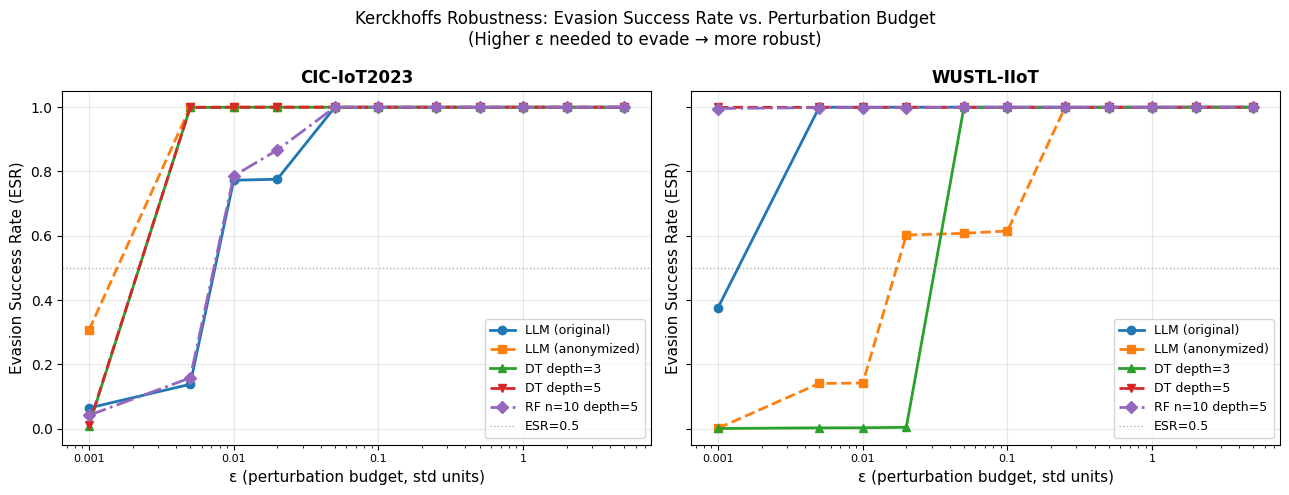

Saved to results/kerckhoffs/robustness_curves.png


In [7]:
################################################################################
# Cell 5 — Robustness curves
################################################################################

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

CSTYLE = {
    'LLM_orig': dict(color='#1f77b4', marker='o', ls='-',  lw=2, label='LLM (original)'),
    'LLM_anon': dict(color='#ff7f0e', marker='s', ls='--', lw=2, label='LLM (anonymized)'),
    'DT_d3':    dict(color='#2ca02c', marker='^', ls='-',  lw=2, label='DT depth=3'),
    'DT_d5':    dict(color='#d62728', marker='v', ls='--', lw=2, label='DT depth=5'),
    'RF_d5':    dict(color='#9467bd', marker='D', ls='-.',  lw=2, label='RF n=10 depth=5'),
}
DS_LABEL = {'cic-iot': 'CIC-IoT2023', 'wustl-iiot': 'WUSTL-IIoT'}

eps_plot = [e for e in EPSILONS if e > 0]  # log scale: skip 0

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (ds_name, ds_res) in zip(axes, all_results.items()):
    for cond in CONDITIONS:
        if cond not in ds_res:
            continue
        ys = [ds_res[cond]['esr'][e] for e in eps_plot]
        st = CSTYLE[cond]
        ax.plot(eps_plot, ys, color=st['color'], marker=st['marker'],
                linestyle=st['ls'], linewidth=st['lw'], label=st['label'], markersize=6)
    ax.set_xscale('log')
    ax.set_xlabel('ε (perturbation budget, std units)', fontsize=11)
    ax.set_ylabel('Evasion Success Rate (ESR)', fontsize=11)
    ax.set_title(DS_LABEL.get(ds_name, ds_name), fontsize=12, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='grey', ls=':', lw=1, alpha=0.6, label='ESR=0.5')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
    ax.tick_params(axis='x', which='both', labelsize=8)

fig.suptitle(
    'Kerckhoffs Robustness: Evasion Success Rate vs. Perturbation Budget\n'
    '(Higher ε needed to evade → more robust)',
    fontsize=12
)
plt.tight_layout()
curve_path = OUT_DIR / 'robustness_curves.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {curve_path}')


In [8]:
################################################################################
# Cell 6 — Median evasion cost table (ε at ESR = 0.5)
################################################################################


def epsilon_at_esr_threshold(epsilons, esrs, target=0.5):
    """Linear interpolation: find ε where ESR curve crosses target."""
    for i in range(len(esrs) - 1):
        if esrs[i] <= target <= esrs[i + 1]:
            span = esrs[i + 1] - esrs[i]
            if span == 0:
                return epsilons[i]
            t = (target - esrs[i]) / span
            return epsilons[i] + t * (epsilons[i + 1] - epsilons[i])
    return float('inf') if esrs[-1] < target else epsilons[0]


table_data = {}
for ds_name, ds_res in all_results.items():
    row = {}
    for cond in CONDITIONS:
        if cond not in ds_res:
            row[cond] = float('inf')
            continue
        esrs = [ds_res[cond]['esr'][e] for e in EPSILONS]
        row[cond] = epsilon_at_esr_threshold(EPSILONS, esrs)
    table_data[ds_name] = row

DS_LABEL = {'cic-iot': 'CIC-IoT', 'wustl-iiot': 'WUSTL-IIoT'}

print('=== KERCKHOFFS ROBUSTNESS RESULTS ===')
print('Median Evasion Cost (ε at ESR=0.5, in std-units)\n')
print('| Dataset    | ' + ' | '.join(f'{c:>8}' for c in CONDITIONS) + ' |')
print('|------------|' + '|'.join(['-'*10] * len(CONDITIONS)) + '|')
for ds_name, row in table_data.items():
    vals = ' | '.join(
        f'{"inf":>8}' if v == float('inf') else f'{v:>8.2f}'
        for v in [row[c] for c in CONDITIONS]
    )
    print(f'| {DS_LABEL.get(ds_name, ds_name):<10} | {vals} |')
print()
print('Higher = more robust.  inf = ESR never reaches 0.5 within ε ≤ 5.0')

# Also print feature_targeting summary at eps=1.0
print('\n--- Top targeted features at ε=1.0 ---')
for ds_name, ds_res in all_results.items():
    print(f'\n{DS_LABEL.get(ds_name, ds_name)}:')
    for cond in CONDITIONS:
        if cond not in ds_res:
            continue
        ft = ds_res[cond]['feature_targeting']
        top3 = sorted(ft.items(), key=lambda kv: kv[1], reverse=True)[:3]
        top3_str = ', '.join(f'{f}({n})' for f, n in top3) if top3 else 'none'
        eps50 = table_data[ds_name][cond]
        eps50_s = 'inf' if eps50 == float('inf') else f'{eps50:.2f}'
        print(f'  {cond:<10}  eps@0.5={eps50_s:>6}  top-features: {top3_str}')


=== KERCKHOFFS ROBUSTNESS RESULTS ===
Median Evasion Cost (ε at ESR=0.5, in std-units)

| Dataset    | LLM_orig | LLM_anon |    DT_d3 |    DT_d5 |    RF_d5 |
|------------|----------|----------|----------|----------|----------|
| CIC-IoT    |     0.01 |     0.00 |     0.00 |     0.00 |     0.01 |
| WUSTL-IIoT |     0.00 |     0.02 |     0.03 |     0.00 |     0.00 |

Higher = more robust.  inf = ESR never reaches 0.5 within ε ≤ 5.0

--- Top targeted features at ε=1.0 ---

CIC-IoT:
  LLM_orig    eps@0.5=  0.01  top-features: Tot sum(5524), Header_Length(4982), Rate(3002)
  LLM_anon    eps@0.5=  0.00  top-features: Covariance(6523), Header_Length(5006), Rate(4003)
  DT_d3       eps@0.5=  0.00  top-features: rst_count(7648), IAT(47), flow_duration(4)
  DT_d5       eps@0.5=  0.00  top-features: rst_count(7668), IAT(52), Covariance(12)
  RF_d5       eps@0.5=  0.01  top-features: urg_count(7078), Header_Length(6981), Covariance(6968)

WUSTL-IIoT:
  LLM_orig    eps@0.5=  0.00  top-features: To

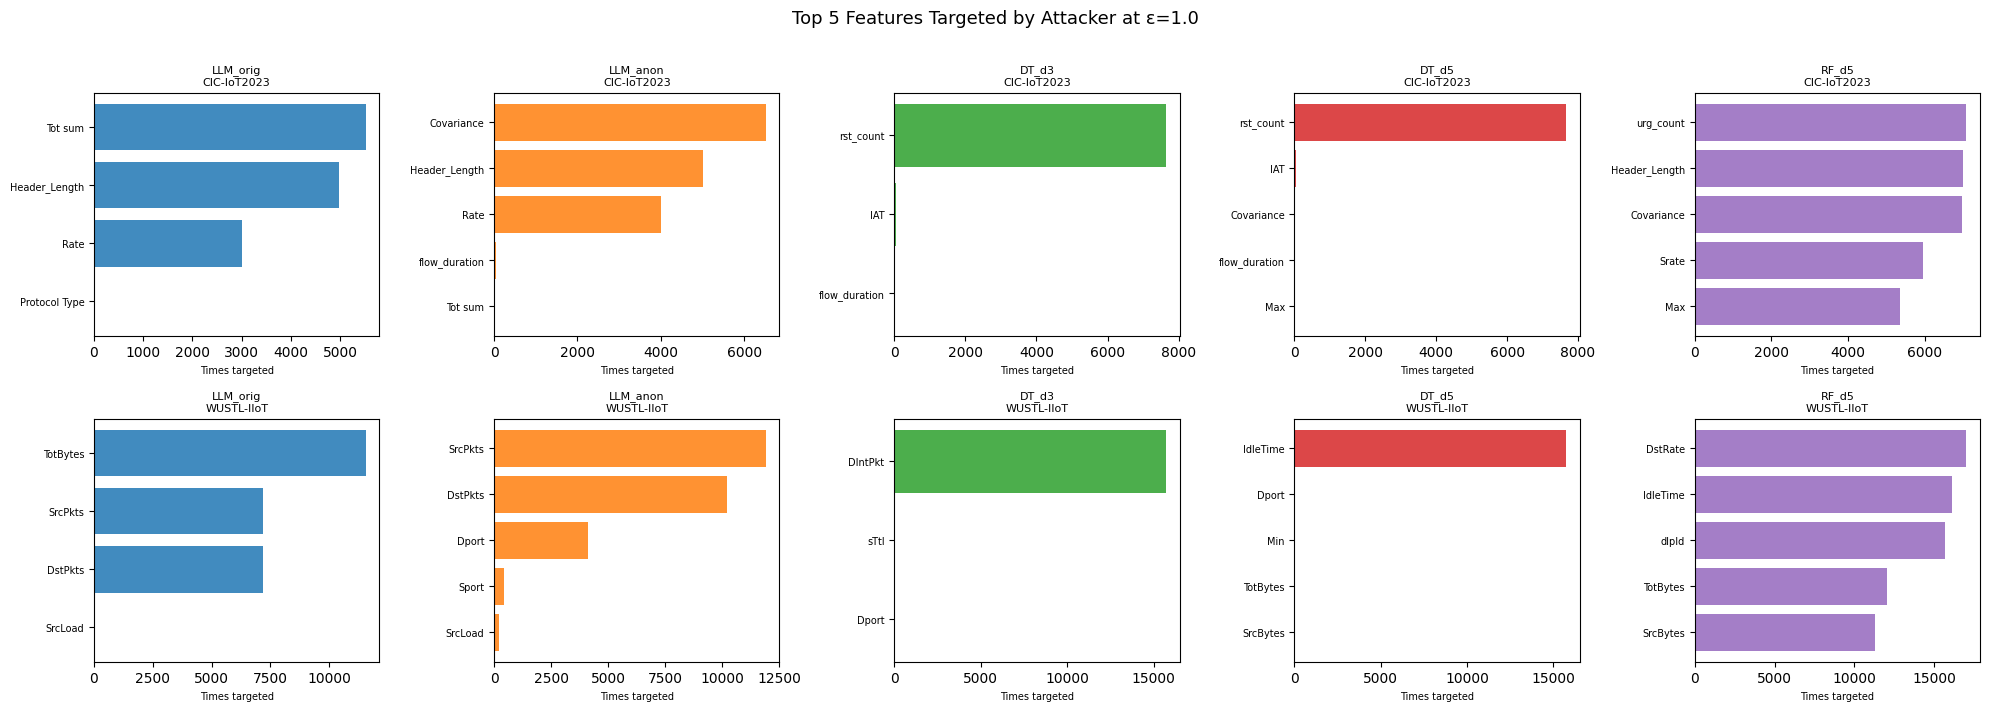

Saved to results/kerckhoffs/feature_targeting.png


In [9]:
################################################################################
# Cell 7 — Per-feature evasion analysis (ε = 1.0)
################################################################################

import matplotlib.pyplot as plt

DS_LABEL = {'cic-iot': 'CIC-IoT2023', 'wustl-iiot': 'WUSTL-IIoT'}
CSTYLE_COLOR = {c: s['color'] for c, s in CSTYLE.items()}

n_ds   = len(all_results)
n_cond = len(CONDITIONS)
fig, axes = plt.subplots(n_ds, n_cond, figsize=(4 * n_cond, 3.5 * n_ds), squeeze=False)

for di, (ds_name, ds_res) in enumerate(all_results.items()):
    for ci, cond in enumerate(CONDITIONS):
        ax = axes[di][ci]
        ax.set_title(f'{cond}\n{DS_LABEL.get(ds_name, ds_name)}', fontsize=8)

        if cond not in ds_res:
            ax.set_visible(False)
            continue

        ft = ds_res[cond]['feature_targeting']
        if not ft:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue

        top5 = sorted(ft.items(), key=lambda kv: kv[1], reverse=True)[:5]
        feats, counts = zip(*top5)
        ax.barh(range(len(feats)), counts, color=CSTYLE_COLOR.get(cond, 'steelblue'), alpha=0.85)
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels([f[:18] for f in feats], fontsize=7)
        ax.set_xlabel('Times targeted', fontsize=7)
        ax.invert_yaxis()

plt.suptitle('Top 5 Features Targeted by Attacker at ε=1.0', fontsize=13, y=1.01)
plt.tight_layout()
feat_path = OUT_DIR / 'feature_targeting.png'
plt.savefig(feat_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {feat_path}')


In [10]:
################################################################################
# Cell 8 — Multi-seed validation
################################################################################

seed_results = {}   # {ds_name: {cond: {seed: eps_at_0.5}}}

for cfg in DATASETS:
    ds_name = cfg['name']
    print(f'\n{ds_name}')
    seed_results[ds_name] = {c: {} for c in CONDITIONS}

    for seed in SEEDS:
        print(f'  seed={seed} ...')
        tr, te, _, fcols, fstds = load_dataset(cfg, seed=seed)
        apool = te[te['binary_label'] == 'attack'].reset_index(drop=True)

        # Retrain ML per seed
        dt3s = train_ml_baseline(DecisionTreeClassifier, tr, fcols,
                                  {'max_depth': 3, 'random_state': seed})
        dt5s = train_ml_baseline(DecisionTreeClassifier, tr, fcols,
                                  {'max_depth': 5, 'random_state': seed})
        rf5s = train_ml_baseline(RandomForestClassifier, tr, fcols,
                                  {'n_estimators': 10, 'max_depth': 5, 'random_state': seed})
        dt3p = extract_dt_attack_paths(dt3s, fcols)
        dt5p = extract_dt_attack_paths(dt5s, fcols)

        # LLM rules: use seed-42 file (per-seed files not generated)
        try:
            ro = load_llm_rules(cfg, 'LLM_orig', seed=SEED_MAIN)
            ra = load_llm_rules(cfg, 'LLM_anon', seed=SEED_MAIN)
        except FileNotFoundError:
            ro, ra = [], []

        conds_s = {
            'LLM_orig': ('llm', ro,   None),
            'LLM_anon': ('llm', ra,   None),
            'DT_d3':    ('dt',  dt3p, None),
            'DT_d5':    ('dt',  dt5p, None),
            'RF_d5':    ('rf',  None, rf5s),
        }

        for cond in CONDITIONS:
            ct, a1, a2 = conds_s[cond]
            if not a1 and ct in ('llm', 'dt'):
                seed_results[ds_name][cond][seed] = float('inf')
                continue
            flagged = []
            for idx in range(len(apool)):
                x = apool.iloc[idx]
                if ct == 'llm' and a1 and predicts_attack_llm(x, a1): flagged.append(idx)
                elif ct == 'dt' and predicts_attack_dt(x, a1): flagged.append(idx)
                elif ct == 'rf' and predicts_attack_rf(x, a2, fcols): flagged.append(idx)

            esr_vals = []
            for eps in EPSILONS:
                if not flagged:
                    esr_vals.append(0.0)
                    continue
                ev_cnt = 0
                for idx in flagged:
                    x = apool.iloc[idx]
                    if ct == 'llm':
                        ev, _, _ = evade_majority_vote(x, a1, fstds, eps)
                    elif ct == 'dt':
                        ev, _, _ = evade_dt(x, a1, fstds, eps)
                    else:
                        ev, _, _ = evade_rf(x, a2, fcols, fstds, eps)
                    if ev: ev_cnt += 1
                esr_vals.append(ev_cnt / len(flagged))

            seed_results[ds_name][cond][seed] = epsilon_at_esr_threshold(EPSILONS, esr_vals)

# Print summary
print('\n=== MULTI-SEED VALIDATION ===')
print(f'ε at ESR=0.5  mean ± std across seeds {SEEDS}\n')
DS_LABEL = {'cic-iot': 'CIC-IoT2023', 'wustl-iiot': 'WUSTL-IIoT'}
for ds_name in seed_results:
    print(f'{DS_LABEL.get(ds_name, ds_name)}:')
    for cond in CONDITIONS:
        vals = list(seed_results[ds_name][cond].values())
        fin  = [v for v in vals if v != float('inf')]
        if not fin:
            print(f'  {cond:<12}: inf (never reaches ESR=0.5)')
        else:
            print(f'  {cond:<12}: {np.mean(fin):.2f} ± {np.std(fin):.2f}'
                  f'  (n_finite={len(fin)}/{len(vals)})')



cic-iot
  seed=42 ...
  [cic-iot] train=63,030  test_known=15,758  zeroday=31,864  features=43
  Loaded 5 LLM_orig rules from zeroday-Mirai-udpplain-seed42-2026-04-20-11-59-41.json
  Loaded 5 LLM_anon rules from zeroday-Mirai-udpplain-anon-ablation-seed42-2026-04-24-11-40-35.json
  seed=123 ...
  [cic-iot] train=63,030  test_known=15,758  zeroday=31,864  features=43
  Loaded 5 LLM_orig rules from zeroday-Mirai-udpplain-seed42-2026-04-20-11-59-41.json
  Loaded 5 LLM_anon rules from zeroday-Mirai-udpplain-anon-ablation-seed42-2026-04-24-11-40-35.json
  seed=456 ...
  [cic-iot] train=63,030  test_known=15,758  zeroday=31,864  features=43
  Loaded 5 LLM_orig rules from zeroday-Mirai-udpplain-seed42-2026-04-20-11-59-41.json
  Loaded 5 LLM_anon rules from zeroday-Mirai-udpplain-anon-ablation-seed42-2026-04-24-11-40-35.json

wustl-iiot
  seed=42 ...
  [wustl-iiot] train=126,041  test_known=31,511  zeroday=8,240  features=43
  Loaded 5 LLM_orig rules from zeroday-Reconn-anon-ablation-seed42-2

In [11]:
################################################################################
# Cell 9 — Save full results JSON
################################################################################

import json, datetime

ts  = datetime.datetime.now().strftime('%Y-%m-%d-%H-%M-%S')
out = {
    'config': {
        'epsilons':   EPSILONS,
        'seeds':      SEEDS,
        'seed_main':  SEED_MAIN,
        'conditions': CONDITIONS,
    },
    'timestamp': ts,
    'datasets': {},
}

DS_LABEL = {'cic-iot': 'CIC-IoT2023', 'wustl-iiot': 'WUSTL-IIoT'}

for cfg in DATASETS:
    ds_name = cfg['name']
    if ds_name not in all_results:
        continue
    ds_out = {
        'withheld_class': cfg['withheld_class'],
        'conditions': {},
    }
    for cond in CONDITIONS:
        if cond not in all_results[ds_name]:
            continue
        res   = all_results[ds_name][cond]
        eps50 = epsilon_at_esr_threshold(EPSILONS, [res['esr'][e] for e in EPSILONS])
        top   = sorted(res['feature_targeting'].items(),
                       key=lambda kv: kv[1], reverse=True)[:10]
        ds_out['conditions'][cond] = {
            'esr_curves':        {str(e): res['esr'][e] for e in EPSILONS},
            'epsilon_at_05':     eps50 if eps50 != float('inf') else 'inf',
            'n_flagged':         res['n_flagged'],
            'feature_targeting': dict(top),
        }

    if ds_name in seed_results:
        ms = {}
        for cond in CONDITIONS:
            svals = seed_results[ds_name][cond]
            fin   = [v for v in svals.values() if v != float('inf')]
            ms[cond] = {
                'per_seed': {str(s): v for s, v in svals.items()},
                'mean':     float(np.mean(fin)) if fin else None,
                'std':      float(np.std(fin))  if fin else None,
            }
        ds_out['multi_seed'] = ms

    out['datasets'][ds_name] = ds_out

out_path = OUT_DIR / f'kerckhoffs-results-{ts}.json'
with open(out_path, 'w') as fh:
    json.dump(out, fh, indent=2)

print(f'Results saved to {out_path}')
# Print first 2000 chars as preview
preview = json.dumps(out, indent=2)
print(preview[:2000] + ('\n...' if len(preview) > 2000 else ''))


Results saved to results/kerckhoffs/kerckhoffs-results-2026-04-28-14-52-13.json
{
  "config": {
    "epsilons": [
      0.0,
      0.001,
      0.005,
      0.01,
      0.02,
      0.05,
      0.1,
      0.25,
      0.5,
      1.0,
      2.0,
      5.0
    ],
    "seeds": [
      42,
      123,
      456
    ],
    "seed_main": 42,
    "conditions": [
      "LLM_orig",
      "LLM_anon",
      "DT_d3",
      "DT_d5",
      "RF_d5"
    ]
  },
  "timestamp": "2026-04-28-14-52-13",
  "datasets": {
    "cic-iot": {
      "withheld_class": "Mirai-udpplain",
      "conditions": {
        "LLM_orig": {
          "esr_curves": {
            "0.0": 0.0,
            "0.001": 0.06432947583390061,
            "0.005": 0.13801906058543226,
            "0.01": 0.7728046289993192,
            "0.02": 0.7758679373723621,
            "0.05": 0.9998298162014976,
            "0.1": 1.0,
            "0.25": 1.0,
            "0.5": 1.0,
            "1.0": 1.0,
            "2.0": 1.0,
            "5.0": 1.0
